# ???(per-exercise) phase head ?? ???

? ???? `phase_experiments/quality_high_per_exercise_head/*/ablation_results.csv`? ??? ??? phase head ??? ???? ??? ?????.

?? ??:
- MLP/LSTM per-exercise head ?? ?? ??
- ???(squat/benchpress/deadlift) phase F1 ??
- ??? count MAE/OBO ??
- ready/down/up phase class F1 ??
- epoch? ?? ??(`history.json`) ??
- ????? high-quality baseline/phase-aux ??? ???? ??

???? ???? ??(`capstone`)?? ?? ??? ???? ????.


In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:  # plain Python fallback
    def display(obj):
        print(obj)
    class Markdown(str):
        pass

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("default")

from matplotlib import font_manager

preferred_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in installed_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 130


## 1) ??

`RUN_DIR = None`?? ?? ?? timestamp ??? ?? ?????. ?? ?? ??? ???? ??? `RUN_DIR`? ?? ??? ????.


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "phase_experiments").exists():
    # Notebook? ?? ???? ??? ?? ???? ?? fallback???.
    fallback = Path(r"C:\Users\kojy1\PycharmProjects\capstone")
    if fallback.exists():
        PROJECT_ROOT = fallback

PER_EXERCISE_ROOT = PROJECT_ROOT / "phase_experiments" / "quality_high_per_exercise_head"
RUN_DIR = None  # ?: PROJECT_ROOT / "phase_experiments/quality_high_per_exercise_head/20260617T072959Z"

SAVE_FIGS = True
FIG_DIR = PROJECT_ROOT / "report_figures" / "per_exercise_head"

COMPARE_WITH_BASELINES = True
EXPORT_TABLES = True

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PER_EXERCISE_ROOT:", PER_EXERCISE_ROOT)
print("FIG_DIR:", FIG_DIR)


PROJECT_ROOT: C:\Users\kojy1\PycharmProjects\capstone
PER_EXERCISE_ROOT: C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head
FIG_DIR: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head


## 2) ??/??? ??


In [3]:
def latest_run_dir(root: Path) -> Path:
    root = Path(root)
    candidates = [p for p in root.iterdir() if p.is_dir() and (p / "ablation_results.csv").exists()]
    if not candidates:
        raise FileNotFoundError(f"No run directory with ablation_results.csv under {root}")
    return sorted(candidates, key=lambda p: p.name)[-1]


def resolve_existing_path(path_like, project_root: Path = PROJECT_ROOT):
    """Resolve Windows absolute paths or repo-relative paths stored inside CSV/JSON artifacts."""
    if path_like is None or (isinstance(path_like, float) and math.isnan(path_like)):
        return None
    raw = str(path_like).strip()
    if not raw or raw.lower() == "nan":
        return None

    normalized = raw.replace("\\", "/")
    candidates = [Path(raw), Path(normalized)]

    marker = "phase_experiments/"
    if marker in normalized:
        candidates.append(project_root / normalized[normalized.index(marker):])

    marker = "report_figures/"
    if marker in normalized:
        candidates.append(project_root / normalized[normalized.index(marker):])

    for candidate in candidates:
        try:
            if candidate.exists():
                return candidate
        except OSError:
            pass
    return None


def force_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    skip = {"exp_name", "checkpoint_path", "latest_path", "history_path", "exp_dir", "output_root", "root", "video_dir", "label_dir", "work_dir", "pose_dir", "meta_csv"}
    for col in out.columns:
        if col not in skip and out[col].dtype == "object":
            converted = pd.to_numeric(out[col], errors="ignore")
            out[col] = converted
    return out


def clean_listish(value) -> str:
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return ""
    text = str(value).strip()
    if text in {"", "[]", "nan", "None"}:
        return ""
    for ch in "[]'\"":
        text = text.replace(ch, "")
    return text.replace(", ", "+").replace(",", "+").strip()


def short_text(text, limit=72) -> str:
    text = str(text)
    return text if len(text) <= limit else text[: limit - 1] + "?"


def make_model_label(row: pd.Series) -> str:
    model = str(row.get("model_type", "model")).upper()
    head = str(row.get("phase_head_type", "head"))
    aux = clean_listish(row.get("phase_aux_inputs", ""))
    deriv = str(row.get("derivative_mode", "pose"))
    pose = str(row.get("pose_backend", ""))
    label_scheme = str(row.get("phase_label_scheme", ""))

    pieces = [model]
    if head and head != "nan":
        pieces.append(head)
    if aux:
        pieces.append(f"aux={aux}")
    elif deriv and deriv not in {"pose", "nan"}:
        pieces.append(f"input={deriv}")
    if "barbell" in pose and "per_exercise" not in head:
        pieces.append("barbell")
    if label_scheme == "bar_direction":
        pieces.append("bar-dir")
    return " | ".join(pieces)


def make_context_label(row: pd.Series) -> str:
    run_kind = str(row.get("run_kind", ""))
    model = str(row.get("model_type", "model")).upper()
    head = str(row.get("phase_head_type", "head"))
    aux = clean_listish(row.get("phase_aux_inputs", ""))
    deriv = str(row.get("derivative_mode", "pose"))
    pose = str(row.get("pose_backend", ""))
    label_scheme = str(row.get("phase_label_scheme", ""))

    if "per_exercise_head" in run_kind or head == "per_exercise_mlp":
        return f"PER-EX {model}"
    if aux:
        return f"AUX {aux} {model}"
    if deriv not in {"pose", "nan", ""}:
        return f"{deriv} {model}"
    if "barbell" in pose and label_scheme == "bar_direction":
        return f"Fusion {head} {model}"
    return f"{head} {model}"


def load_ablation_csv(path: Path, source_label=None) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_csv(path)
    df = force_numeric(df)
    df["_csv_path"] = str(path)
    df["_source_label"] = source_label or path.parent.name
    df["_run_dir"] = str(path.parent)
    df["model_label"] = df.apply(make_model_label, axis=1)
    df["context_label"] = df.apply(make_context_label, axis=1)
    return df


def savefig(fig, name: str):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        path = FIG_DIR / name
        fig.savefig(path, bbox_inches="tight")
        print(f"saved: {path}")


def annotate_bars(ax, bars, fmt="{:.3f}", fontsize=8, pad=0.01):
    ylim = ax.get_ylim()
    span = ylim[1] - ylim[0]
    for bar in bars:
        height = bar.get_height()
        if pd.isna(height):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + span * pad,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=0,
        )


def grouped_bar(ax, data: pd.DataFrame, x_col: str, y_col: str, hue_col: str, title: str, ylabel: str, ylim=None, fmt="{:.3f}"):
    x_vals = list(data[x_col].dropna().unique())
    hue_vals = list(data[hue_col].dropna().unique())
    x = np.arange(len(x_vals))
    width = min(0.8 / max(len(hue_vals), 1), 0.35)
    cmap = plt.get_cmap("tab10")

    for i, hue in enumerate(hue_vals):
        subset = data[data[hue_col] == hue].set_index(x_col)
        vals = [subset[y_col].get(xv, np.nan) for xv in x_vals]
        offsets = x + (i - (len(hue_vals) - 1) / 2) * width
        bars = ax.bar(offsets, vals, width=width, label=hue, color=cmap(i))
        annotate_bars(ax, bars, fmt=fmt, fontsize=7, pad=0.008)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(x_vals, rotation=0)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(loc="best", fontsize=8)
    ax.grid(axis="y", alpha=0.25)


def export_table(df: pd.DataFrame, name: str):
    if EXPORT_TABLES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        path = FIG_DIR / name
        df.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"exported: {path}")


## 3) ??? head ?? ?? ??


In [4]:
run_dir = Path(RUN_DIR) if RUN_DIR is not None else latest_run_dir(PER_EXERCISE_ROOT)
results_path = run_dir / "ablation_results.csv"
results = load_ablation_csv(results_path, source_label="per_exercise_head")

sort_cols = [c for c in ["model_type", "best_val_score"] if c in results.columns]
results = results.sort_values(sort_cols, ascending=[True, False] if len(sort_cols) == 2 else True).reset_index(drop=True)

metric_cols = [
    "model_label", "best_epoch", "best_val_score", "video_action_f1", "video_phase_f1", "phase_macro_f1",
    "video_count_mae", "video_count_obo", "ready_f1", "down_f1", "up_f1",
    "phase_macro_f1_squat", "phase_macro_f1_benchpress", "phase_macro_f1_deadlift",
    "mae_squat", "obo_squat", "mae_benchpress", "obo_benchpress", "mae_deadlift", "obo_deadlift",
    "history_path", "checkpoint_path",
]
metric_cols = [c for c in metric_cols if c in results.columns]

summary = results[metric_cols].copy()
for col in summary.select_dtypes(include="number").columns:
    summary[col] = summary[col].round(4)

display(Markdown(f"**Loaded run:** `{run_dir}`  "))
display(summary)
export_table(summary, "per_exercise_head_summary.csv")


**Loaded run:** `C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z`  

,model_label,best_epoch,best_val_score,video_action_f1,video_phase_f1,phase_macro_f1,video_count_mae,video_count_obo,ready_f1,down_f1,up_f1,phase_macro_f1_squat,phase_macro_f1_benchpress,phase_macro_f1_deadlift,mae_squat,obo_squat,mae_benchpress,obo_benchpress,mae_deadlift,obo_deadlift,history_path,checkpoint_path
0,LSTM | per_exercise_mlp | bar-dir,6,1.6692,1.0,0.7289,0.7289,0.6667,0.9333,0.6450,0.7513,0.7905,0.8068,0.5255,0.5462,0.2857,1.0,1.1667,0.8333,0.5,1.0,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\mediapipe_...,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\mediapipe_...
1,MLP | per_exercise_mlp | bar-dir,20,1.6690,1.0,0.7289,0.7289,0.8000,0.8667,0.6273,0.7821,0.7774,0.8024,0.5148,0.5557,0.4286,1.0,1.0000,0.8333,1.5,0.5,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\mediapipe_...,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\mediapipe_...


exported: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\per_exercise_head_summary.csv


## 4) ?? ?? ?? ??

- `best_val_score`, `video/action/phase F1`, `OBO`? ???? ????.
- `count MAE`? ???? ????.


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\overall_metrics.png


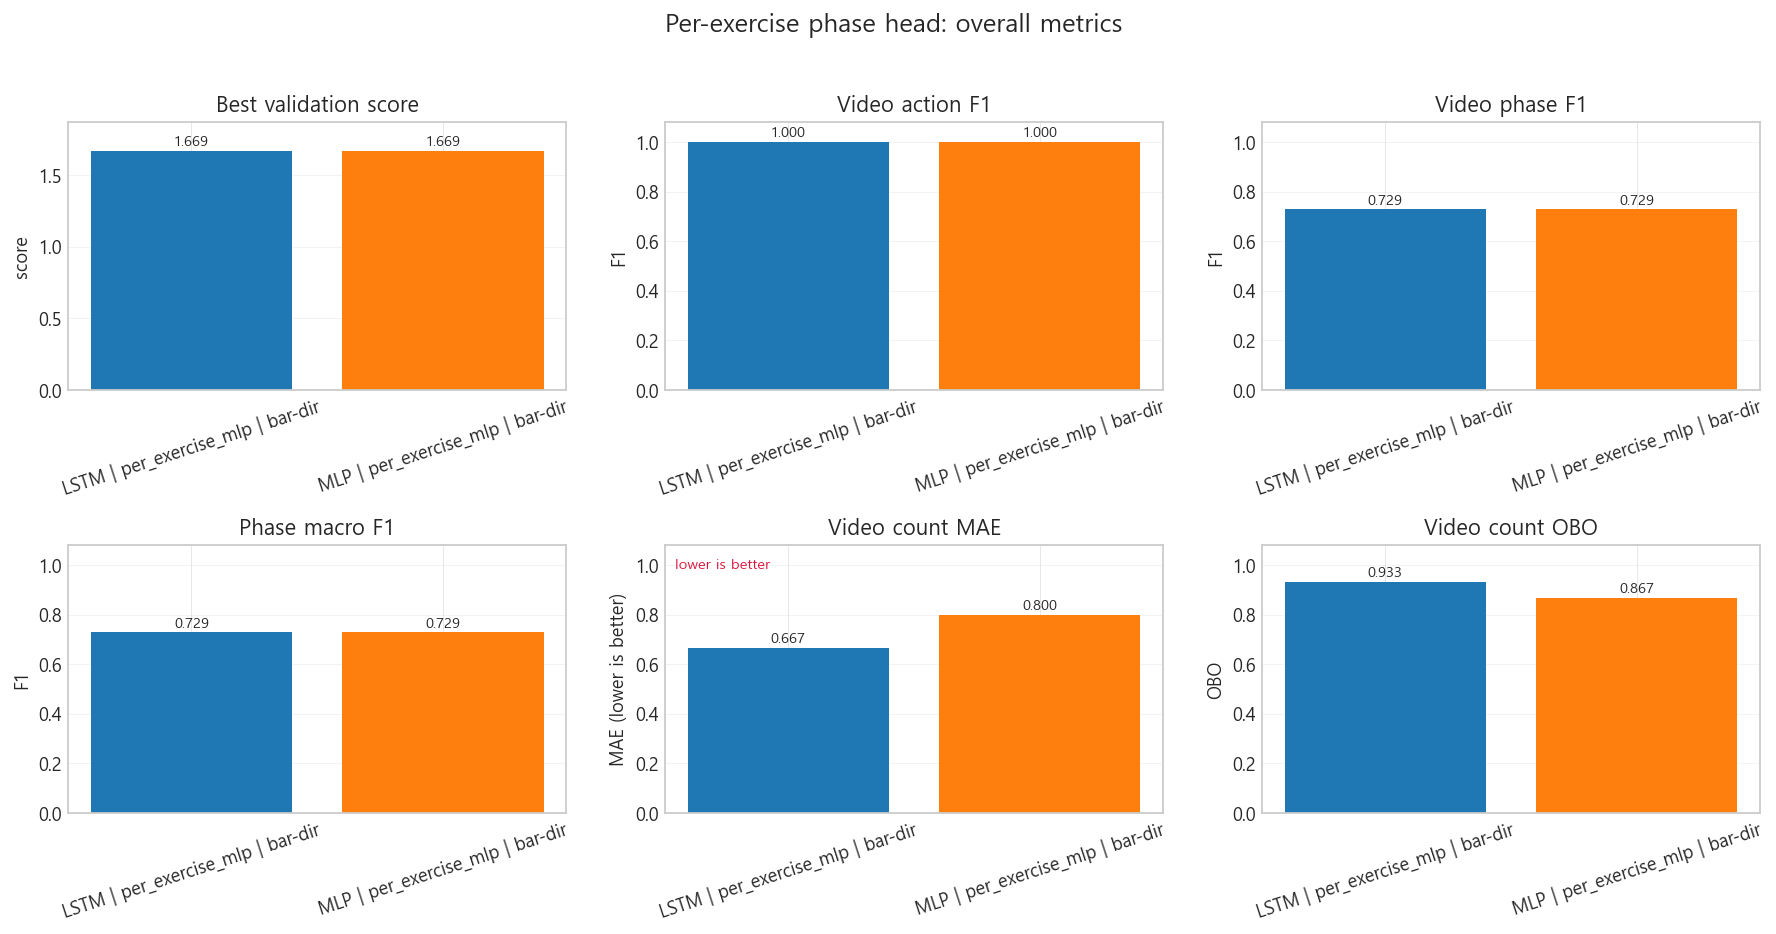

In [5]:
overall_specs = [
    ("best_val_score", "Best validation score", "score", True),
    ("video_action_f1", "Video action F1", "F1", True),
    ("video_phase_f1", "Video phase F1", "F1", True),
    ("phase_macro_f1", "Phase macro F1", "F1", True),
    ("video_count_mae", "Video count MAE", "MAE (lower is better)", False),
    ("video_count_obo", "Video count OBO", "OBO", True),
]

available_specs = [spec for spec in overall_specs if spec[0] in results.columns]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
colors = plt.get_cmap("tab10")(np.arange(len(results)))

for ax, (col, title, ylabel, higher_is_better) in zip(axes, available_specs):
    plot_df = results[["model_label", col]].dropna().copy()
    bars = ax.bar(plot_df["model_label"], plot_df[col], color=colors[: len(plot_df)])
    annotate_bars(ax, bars)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelrotation=18)
    ax.grid(axis="y", alpha=0.25)
    if plot_df[col].max() <= 1.05 and plot_df[col].min() >= 0:
        ax.set_ylim(0, 1.08)
    else:
        ymin = 0 if higher_is_better else max(0, plot_df[col].min() * 0.85)
        ymax = plot_df[col].max() * 1.12 if plot_df[col].max() > 0 else 1
        ax.set_ylim(ymin, ymax)
    if not higher_is_better:
        ax.text(0.02, 0.95, "lower is better", transform=ax.transAxes, va="top", fontsize=8, color="crimson")

for ax in axes[len(available_specs):]:
    ax.axis("off")

fig.suptitle("Per-exercise phase head: overall metrics", y=1.02, fontsize=14)
fig.tight_layout()
savefig(fig, "overall_metrics.png")
plt.show()


## 5) ??? phase F1


exercise,benchpress,deadlift,squat
model,,,
LSTM | per_exercise_mlp | bar-dir,0.5255,0.5462,0.8068
MLP | per_exercise_mlp | bar-dir,0.5148,0.5557,0.8024


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\phase_f1_by_exercise.png


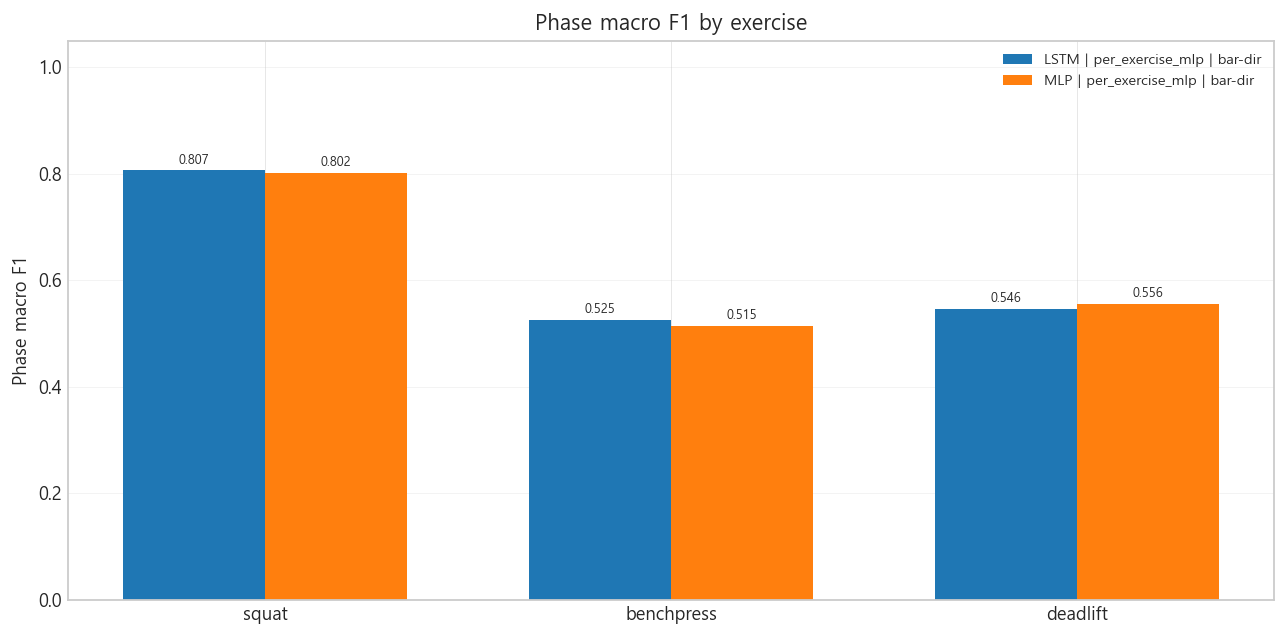

In [6]:
exercise_order = ["squat", "benchpress", "deadlift"]
phase_f1_cols = {ex: f"phase_macro_f1_{ex}" for ex in exercise_order}
phase_long = []
for _, row in results.iterrows():
    for ex, col in phase_f1_cols.items():
        if col in results.columns:
            phase_long.append({"model": row["model_label"], "exercise": ex, "phase_f1": row[col]})
phase_long = pd.DataFrame(phase_long)

display(phase_long.pivot(index="model", columns="exercise", values="phase_f1").round(4))

fig, ax = plt.subplots(figsize=(10, 5))
grouped_bar(ax, phase_long, "exercise", "phase_f1", "model", "Phase macro F1 by exercise", "Phase macro F1", ylim=(0, 1.05))
fig.tight_layout()
savefig(fig, "phase_f1_by_exercise.png")
plt.show()


## 6) ??? count MAE / OBO


metric                                           MAE     OBO
model                             exercise                  
LSTM | per_exercise_mlp | bar-dir benchpress  1.1667  0.8333
                                  deadlift    0.5000  1.0000
                                  squat       0.2857  1.0000
MLP | per_exercise_mlp | bar-dir  benchpress  1.0000  0.8333
                                  deadlift    1.5000  0.5000
                                  squat       0.4286  1.0000

saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\count_metrics_by_exercise.png


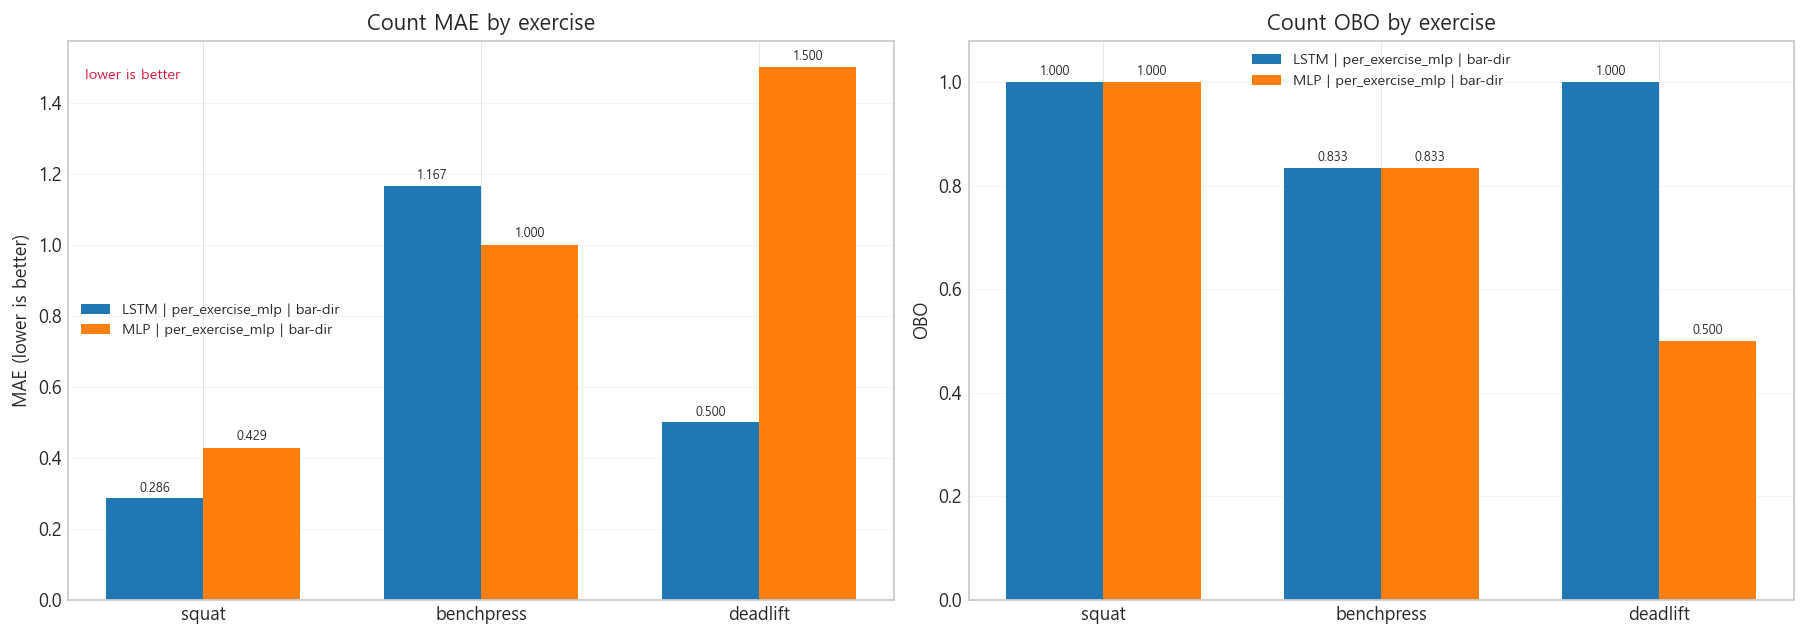

In [7]:
count_rows = []
for _, row in results.iterrows():
    for ex in exercise_order:
        mae_col = f"mae_{ex}"
        obo_col = f"obo_{ex}"
        if mae_col in results.columns:
            count_rows.append({"model": row["model_label"], "exercise": ex, "metric": "MAE", "value": row[mae_col]})
        if obo_col in results.columns:
            count_rows.append({"model": row["model_label"], "exercise": ex, "metric": "OBO", "value": row[obo_col]})
count_long = pd.DataFrame(count_rows)

display(count_long.pivot_table(index=["model", "exercise"], columns="metric", values="value").round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mae_df = count_long[count_long["metric"] == "MAE"]
obo_df = count_long[count_long["metric"] == "OBO"]

grouped_bar(axes[0], mae_df, "exercise", "value", "model", "Count MAE by exercise", "MAE (lower is better)")
axes[0].text(0.02, 0.95, "lower is better", transform=axes[0].transAxes, va="top", fontsize=8, color="crimson")
grouped_bar(axes[1], obo_df, "exercise", "value", "model", "Count OBO by exercise", "OBO", ylim=(0, 1.08))

fig.tight_layout()
savefig(fig, "count_metrics_by_exercise.png")
plt.show()


## 7) Phase class? F1: ready / down / up


phase_class,down,ready,up
model,,,
LSTM | per_exercise_mlp | bar-dir,0.7513,0.6450,0.7905
MLP | per_exercise_mlp | bar-dir,0.7821,0.6273,0.7774


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\phase_class_f1.png


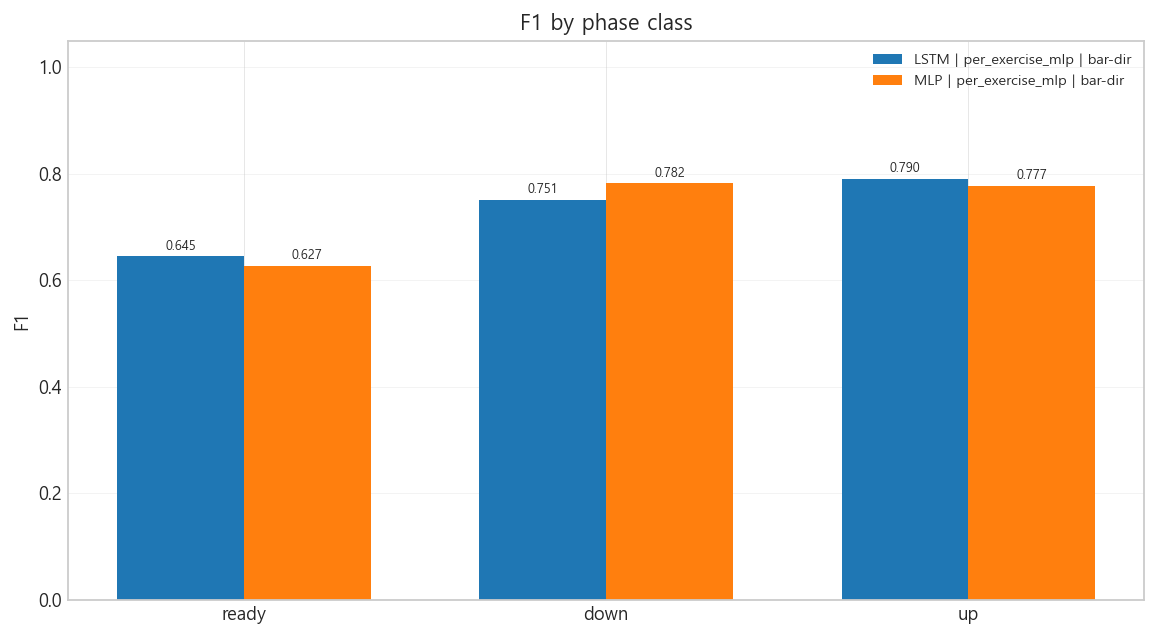

In [8]:
class_cols = {"ready": "ready_f1", "down": "down_f1", "up": "up_f1"}
class_rows = []
for _, row in results.iterrows():
    for phase_name, col in class_cols.items():
        if col in results.columns:
            class_rows.append({"model": row["model_label"], "phase_class": phase_name, "f1": row[col]})
class_long = pd.DataFrame(class_rows)

display(class_long.pivot(index="model", columns="phase_class", values="f1").round(4))

fig, ax = plt.subplots(figsize=(9, 5))
grouped_bar(ax, class_long, "phase_class", "f1", "model", "F1 by phase class", "F1", ylim=(0, 1.05))
fig.tight_layout()
savefig(fig, "phase_class_f1.png")
plt.show()


## 8) `history.json` ?? ??

CSV? `history_path`? ?????. ?? ??? ?? ???? ??? `phase_experiments/...` ?? ??? ???? ?? ???? ?? ?????.


history rows: (60, 9)


,model,epoch,history_path,best_epoch,train_loss,val_action_acc,val_action_f1,val_phase_acc,val_phase_f1
29,LSTM | per_exercise_mlp | bar-dir,30,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\mediapipe_...,6,0.5406,0.9338,0.8691,0.6687,0.6635
59,MLP | per_exercise_mlp | bar-dir,30,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\mediapipe_...,20,0.6839,0.9518,0.9090,0.7468,0.7400


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\history_curves.png


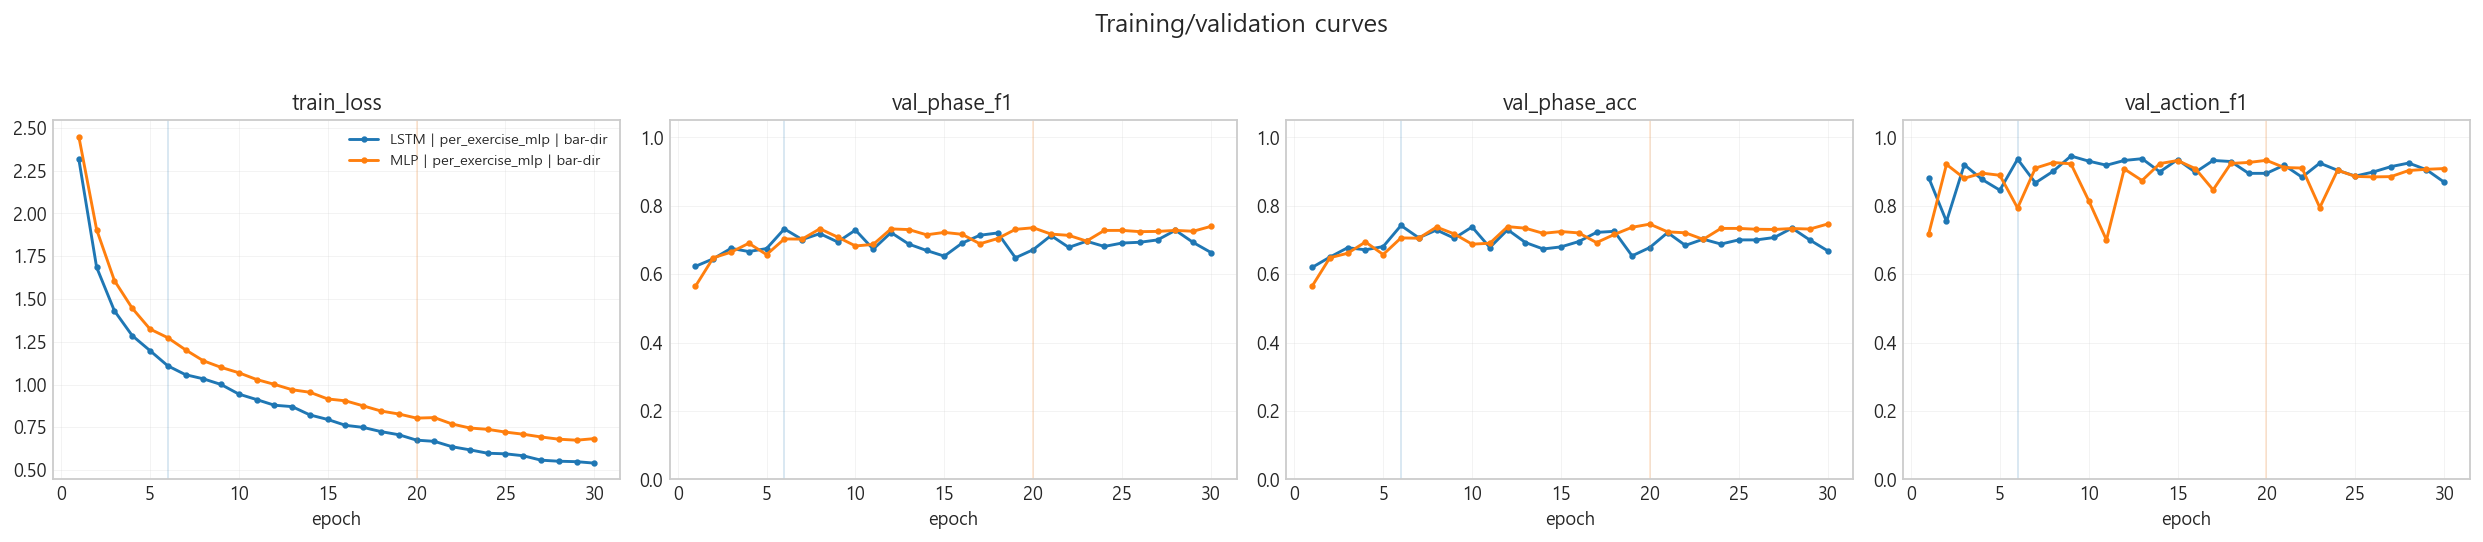

In [9]:
def load_history_frame(results_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in results_df.iterrows():
        history_path = resolve_existing_path(row.get("history_path"))
        if history_path is None:
            print("missing history:", row.get("history_path"))
            continue
        with open(history_path, "r", encoding="utf-8") as f:
            hist = json.load(f)
        list_keys = [k for k, v in hist.items() if isinstance(v, list)]
        if not list_keys:
            continue
        max_len = max(len(hist[k]) for k in list_keys)
        for i in range(max_len):
            rec = {
                "model": row["model_label"],
                "epoch": i + 1,
                "history_path": str(history_path),
                "best_epoch": row.get("best_epoch", np.nan),
            }
            for k in list_keys:
                rec[k] = hist[k][i] if i < len(hist[k]) else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

hist_df = load_history_frame(results)
print("history rows:", hist_df.shape)

if hist_df.empty:
    display(Markdown("history.json? ?? ?????."))
else:
    display(hist_df.groupby("model").tail(1).round(4))

    history_metrics = [m for m in ["train_loss", "val_phase_f1", "val_phase_acc", "val_action_f1"] if m in hist_df.columns]
    fig, axes = plt.subplots(1, len(history_metrics), figsize=(4.8 * len(history_metrics), 4), squeeze=False)
    axes = axes.ravel()
    cmap = plt.get_cmap("tab10")

    for ax, metric in zip(axes, history_metrics):
        for i, (model, g) in enumerate(hist_df.groupby("model", sort=False)):
            ax.plot(g["epoch"], g[metric], marker="o", ms=2.5, lw=1.6, label=model, color=cmap(i))
            best_epoch = g["best_epoch"].dropna()
            if not best_epoch.empty:
                be = int(best_epoch.iloc[0])
                ax.axvline(be, color=cmap(i), alpha=0.18, lw=1)
        ax.set_title(metric)
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.25)
        if metric != "train_loss":
            ax.set_ylim(0, 1.05)
    axes[0].legend(loc="best", fontsize=8)
    fig.suptitle("Training/validation curves", y=1.03, fontsize=14)
    fig.tight_layout()
    savefig(fig, "history_curves.png")
    plt.show()


## 9) ??: high-quality baseline / phase-aux ??? ??

`COMPARE_WITH_BASELINES=True`? ? ?????. ??/?????? per-exercise head? ?? high-quality ?? ?? ??? ????? ??? ?? ?????.


,context_label,model_type,phase_head_type,derivative_mode,phase_aux_inputs,phase_label_scheme,best_epoch,best_val_score,phase_macro_f1,video_phase_f1,video_count_mae,video_count_obo,phase_macro_f1_squat,phase_macro_f1_benchpress,phase_macro_f1_deadlift,_csv_path
0,AUX barbell LSTM,lstm,exercise_attn,pose,['barbell'],bar_direction,14,1.6608,0.7580,0.7580,0.8000,0.8000,0.8252,0.4936,0.5956,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_phase_aux_inputs\20260617T144404Z\ablation_re...
1,AUX wrist LSTM,lstm,exercise_attn,pose,['wrist'],bar_direction,16,1.6828,0.7491,0.7491,1.1333,0.8000,0.8151,0.5257,0.5994,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_phase_aux_inputs\20260617T144404Z\ablation_re...
2,Fusion exercise_attn MLP,mlp,exercise_attn,pose,NaN,bar_direction,28,1.6760,0.7454,0.7454,0.8667,0.8667,0.8280,0.5223,0.5398,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_filter_best_arch\20260615T004443Z\high_mediapipe_b...
3,Fusion exercise_attn LSTM,lstm,exercise_attn,pose,NaN,bar_direction,28,1.6787,0.7431,0.7431,1.2000,0.8667,0.7940,0.5715,0.6451,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_filter_best_arch_lstm\20260615T020450Z\high_mediap...
4,exercise_attn MLP,mlp,exercise_attn,pose,NaN,as_labeled,28,1.6632,0.7424,0.7424,1.0000,0.9333,0.8229,0.4917,0.5515,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_filter_best_arch\20260615T004443Z\high_exercise_at...
5,PER-EX MLP,mlp,per_exercise_mlp,pose,NaN,bar_direction,20,1.6690,0.7289,0.7289,0.8000,0.8667,0.8024,0.5148,0.5557,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\ablation_r...
6,PER-EX LSTM,lstm,per_exercise_mlp,pose,NaN,bar_direction,6,1.6692,0.7289,0.7289,0.6667,0.9333,0.8068,0.5255,0.5462,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_per_exercise_head\20260617T072959Z\ablation_r...
7,acceleration LSTM,lstm,mlp,acceleration,NaN,as_labeled,10,1.6657,0.7287,0.7287,0.6667,0.8667,0.8094,0.6107,0.3743,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_filter_best_arch_lstm\20260615T020450Z\high_accele...
8,AUX acceleration LSTM,lstm,exercise_attn,pose,['acceleration'],bar_direction,11,1.6632,0.7253,0.7253,1.8000,0.8000,0.8221,0.5748,0.2748,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_high_phase_aux_inputs\20260617T144404Z\ablation_re...
9,exercise_attn LSTM,lstm,exercise_attn,pose,NaN,as_labeled,11,1.6623,0.7227,0.7227,0.8667,0.8000,0.7947,0.4736,0.5648,C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\quality_filter_best_arch_lstm\20260615T020450Z\high_exerci...


exported: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\per_exercise_head_context_comparison.csv
saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\context_core_metrics.png


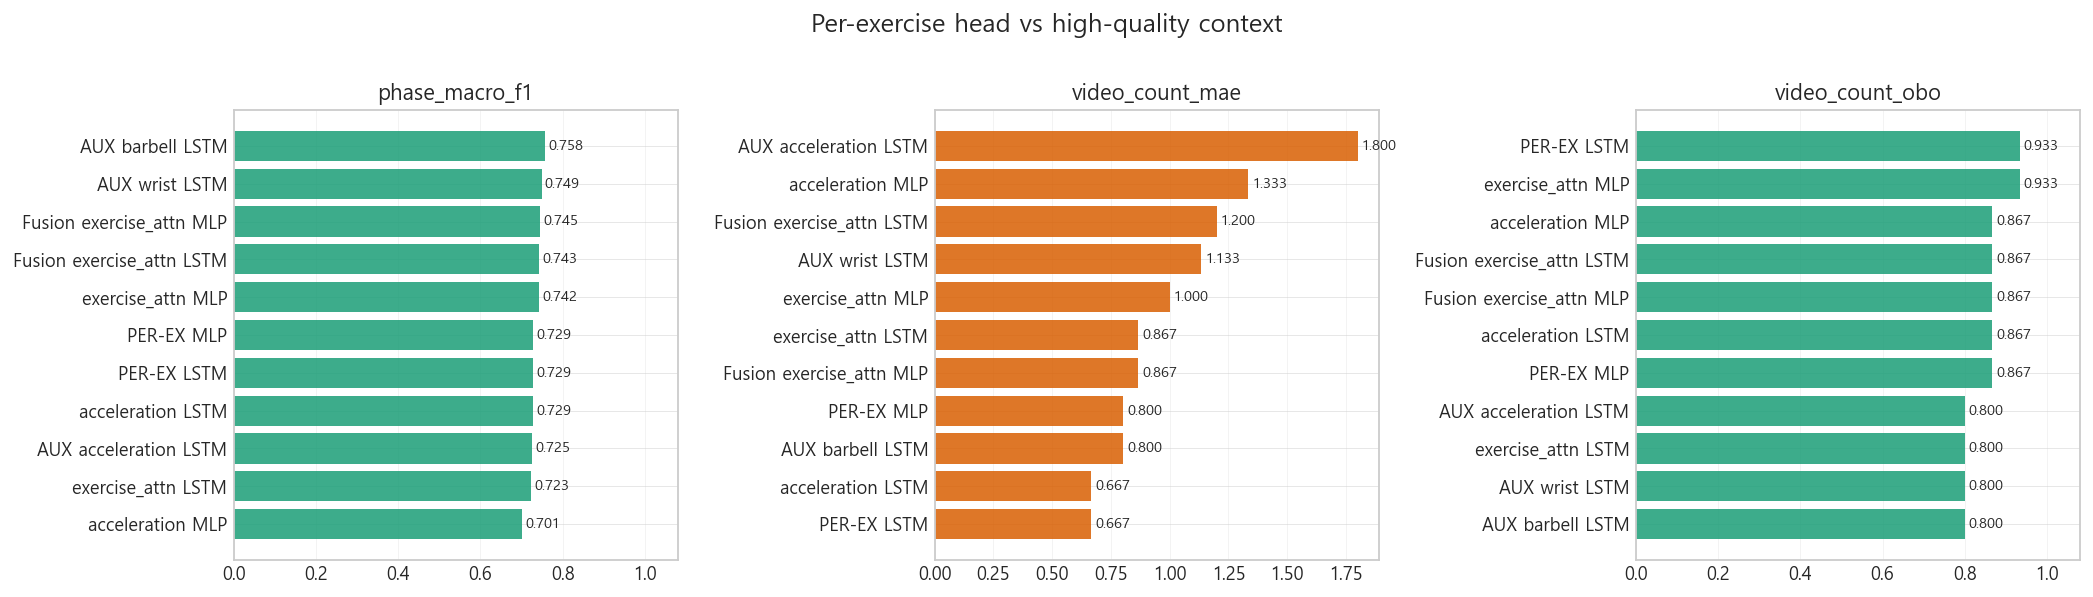

saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\per_exercise_head\context_exercise_phase_f1_heatmap.png


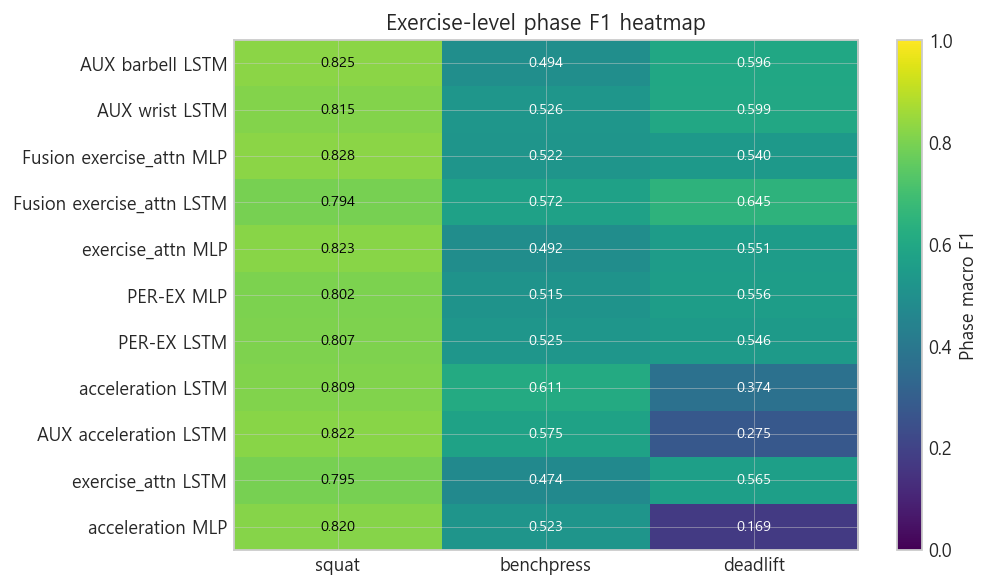

In [10]:
def discover_context_csvs(project_root: Path) -> list[Path]:
    patterns = [
        "phase_experiments/quality_filter_best_arch/*/*/ablation_results.csv",
        "phase_experiments/quality_filter_best_arch_lstm/*/*/ablation_results.csv",
        "phase_experiments/quality_high_phase_aux_inputs/*/ablation_results.csv",
        "phase_experiments/quality_high_per_exercise_head/*/ablation_results.csv",
    ]
    paths = []
    for pattern in patterns:
        paths.extend(project_root.glob(pattern))
    return sorted(set(paths))

if not COMPARE_WITH_BASELINES:
    display(Markdown("Baseline comparison disabled."))
else:
    context_paths = discover_context_csvs(PROJECT_ROOT)
    frames = []
    for path in context_paths:
        try:
            frames.append(load_ablation_csv(path, source_label=path.parent.name))
        except Exception as exc:
            print("skip", path, exc)

    if not frames:
        display(Markdown("??? ablation_results.csv? ?? ?????."))
    else:
        context = pd.concat(frames, ignore_index=True, sort=False)
        if "completion_status" in context.columns:
            context = context[(context["completion_status"].isna()) | (context["completion_status"].astype(str).eq("complete"))]

        # ?? exp_name? ?? ? ???? ??? ??? ?????.
        if "exp_name" in context.columns:
            context = context.drop_duplicates(subset=["exp_name"], keep="last")

        # ?? ?? ??: phase F1 ??, ??? best score
        sort_col = "phase_macro_f1" if "phase_macro_f1" in context.columns else "best_val_score"
        context = context.sort_values(sort_col, ascending=False).reset_index(drop=True)

        context_cols = [
            "context_label", "model_type", "phase_head_type", "derivative_mode", "phase_aux_inputs", "phase_label_scheme",
            "best_epoch", "best_val_score", "phase_macro_f1", "video_phase_f1", "video_count_mae", "video_count_obo",
            "phase_macro_f1_squat", "phase_macro_f1_benchpress", "phase_macro_f1_deadlift", "_csv_path",
        ]
        context_cols = [c for c in context_cols if c in context.columns]
        context_summary = context[context_cols].copy()
        for col in context_summary.select_dtypes(include="number").columns:
            context_summary[col] = context_summary[col].round(4)

        display(context_summary)
        export_table(context_summary, "per_exercise_head_context_comparison.csv")

        # ?? ?? bar: phase F1 / count MAE / OBO
        plot_context = context.copy()
        plot_context["plot_label"] = plot_context["context_label"]
        # label ?? ??
        counts = plot_context["plot_label"].value_counts()
        dup_seen = {}
        labels = []
        for _, row in plot_context.iterrows():
            label = row["plot_label"]
            if counts[label] > 1:
                dup_seen[label] = dup_seen.get(label, 0) + 1
                label = f"{label} #{dup_seen[label]}"
            labels.append(label)
        plot_context["plot_label"] = labels

        metric_triplet = [m for m in ["phase_macro_f1", "video_count_mae", "video_count_obo"] if m in plot_context.columns]
        fig, axes = plt.subplots(1, len(metric_triplet), figsize=(5.4 * len(metric_triplet), max(4.5, 0.35 * len(plot_context))))
        if len(metric_triplet) == 1:
            axes = [axes]
        for ax, metric in zip(axes, metric_triplet):
            if metric == "video_count_mae":
                tmp = plot_context[["plot_label", metric]].dropna().sort_values(metric, ascending=True)
                color = "#d95f02"
            else:
                tmp = plot_context[["plot_label", metric]].dropna().sort_values(metric, ascending=True)
                color = "#1b9e77"
            bars = ax.barh(tmp["plot_label"], tmp[metric], color=color, alpha=0.85)
            ax.set_title(metric)
            ax.grid(axis="x", alpha=0.25)
            for bar in bars:
                w = bar.get_width()
                ax.text(w + max(tmp[metric].max(), 1e-9) * 0.01, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va="center", fontsize=8)
            if metric != "video_count_mae" and tmp[metric].max() <= 1.05:
                ax.set_xlim(0, 1.08)
        fig.suptitle("Per-exercise head vs high-quality context", y=1.01, fontsize=14)
        fig.tight_layout()
        savefig(fig, "context_core_metrics.png")
        plt.show()

        # ??? F1 heatmap
        ex_cols = [f"phase_macro_f1_{ex}" for ex in exercise_order if f"phase_macro_f1_{ex}" in plot_context.columns]
        if ex_cols:
            heat = plot_context.set_index("plot_label")[ex_cols].copy()
            heat.columns = [c.replace("phase_macro_f1_", "") for c in heat.columns]
            heat = heat.dropna(how="all")
            fig_h = max(4.5, 0.42 * len(heat))
            fig, ax = plt.subplots(figsize=(8, fig_h))
            im = ax.imshow(heat.values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
            ax.set_xticks(np.arange(len(heat.columns)))
            ax.set_xticklabels(heat.columns)
            ax.set_yticks(np.arange(len(heat.index)))
            ax.set_yticklabels(heat.index)
            ax.set_title("Exercise-level phase F1 heatmap")
            for i in range(heat.shape[0]):
                for j in range(heat.shape[1]):
                    val = heat.iloc[i, j]
                    if pd.notna(val):
                        ax.text(j, i, f"{val:.3f}", ha="center", va="center", color="white" if val < 0.65 else "black", fontsize=8)
            cbar = fig.colorbar(im, ax=ax)
            cbar.set_label("Phase macro F1")
            fig.tight_layout()
            savefig(fig, "context_exercise_phase_f1_heatmap.png")
            plt.show()


## 10) ?? ?? ???

?? ?? ?? ??? per-exercise head ???? ??? ??? ???? ?????.


In [11]:
def best_row(df: pd.DataFrame, metric: str, higher=True):
    if metric not in df.columns:
        return None
    s = pd.to_numeric(df[metric], errors="coerce")
    if s.dropna().empty:
        return None
    idx = s.idxmax() if higher else s.idxmin()
    return df.loc[idx, "model_label"], s.loc[idx]

checks = [
    ("best_val_score", True, "best validation score"),
    ("phase_macro_f1", True, "overall phase macro F1"),
    ("video_count_mae", False, "count MAE"),
    ("video_count_obo", True, "count OBO"),
    ("phase_macro_f1_squat", True, "squat phase F1"),
    ("phase_macro_f1_benchpress", True, "benchpress phase F1"),
    ("phase_macro_f1_deadlift", True, "deadlift phase F1"),
]

lines = ["### Auto summary"]
for metric, higher, label in checks:
    out = best_row(results, metric, higher=higher)
    if out is None:
        continue
    model, value = out
    direction = "highest" if higher else "lowest"
    lines.append(f"- **{label}**: {model} ({direction}, {value:.4f})")

display(Markdown("\n".join(lines)))


### Auto summary
- **best validation score**: LSTM | per_exercise_mlp | bar-dir (highest, 1.6692)
- **overall phase macro F1**: MLP | per_exercise_mlp | bar-dir (highest, 0.7289)
- **count MAE**: LSTM | per_exercise_mlp | bar-dir (lowest, 0.6667)
- **count OBO**: LSTM | per_exercise_mlp | bar-dir (highest, 0.9333)
- **squat phase F1**: LSTM | per_exercise_mlp | bar-dir (highest, 0.8068)
- **benchpress phase F1**: LSTM | per_exercise_mlp | bar-dir (highest, 0.5255)
- **deadlift phase F1**: MLP | per_exercise_mlp | bar-dir (highest, 0.5557)